In [4]:
#¿Por que una empresa podría no compartir sus datos reales? Para seguridad de la misma empresa 

In [3]:
#¿Qué sesgos existen al utilizar información personal de clientes?  la perdida de datos sensibles del mismo cliente surgiendo posibles demandas a la empresa

In [4]:
#¿Crees que es posible entrenar un modelo de ML sin utilizar datos reales? Si pero solo para practicas.

In [8]:
pip install faker


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 374.0 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 374.0 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 374.0 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 374.0 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 374.0 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 37

In [1]:
#importar librerias 
from faker import Faker
import pandas as pd 
import random

In [2]:
#Creamos una instancia de Faker
fake = Faker("es_MX")

In [28]:
#Generamos datos sinteticos: 100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(
            ["TikTok","Instagram","Youtube"]
        )
    })

In [29]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Cristian José Carlos Ballesteros Báez,osaavedra@example.net,60,44443,TikTok
1,2,María Ariadna Cantú,uchacon@example.org,47,44221,Instagram
2,3,Ing. Mauro Caldera,jaquelinegodinez@example.org,61,33654,TikTok
3,4,Dr. Rolando Chapa,martin65@example.net,21,11781,Youtube
4,5,Zacarías Brito,aapodaca@example.net,20,48594,Youtube


In [30]:
#Exploración del Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      1000 non-null   object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [31]:
#Estadistica descriptiva 
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,1000,1000,NaN,NaN,3
top,NaN,Lic. Georgina Lira,esperanzavigil@example.com,NaN,NaN,Instagram
freq,NaN,1,1,NaN,NaN,346
mean,500.500000,NaN,NaN,41.241000,25468.876000,NaN
std,288.819436,NaN,NaN,14.050564,14115.700289,NaN
min,1.000000,NaN,NaN,18.000000,128.000000,NaN
25%,250.750000,NaN,NaN,29.000000,13942.750000,NaN
50%,500.500000,NaN,NaN,41.000000,25223.500000,NaN
75%,750.250000,NaN,NaN,54.000000,37797.500000,NaN


In [32]:
#importar librerias para graficar
import seaborn as sns 
import matplotlib.pyplot as plt

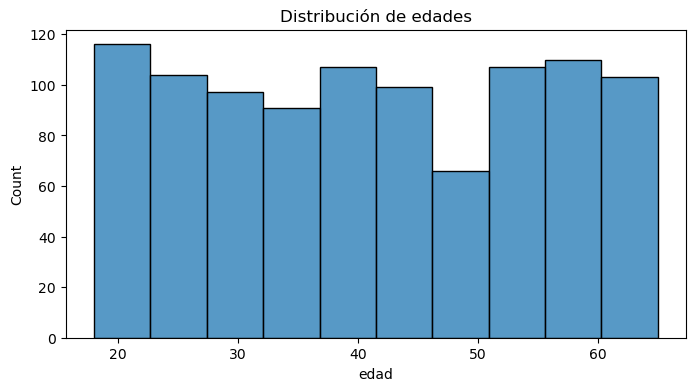

In [33]:
#Distribución de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

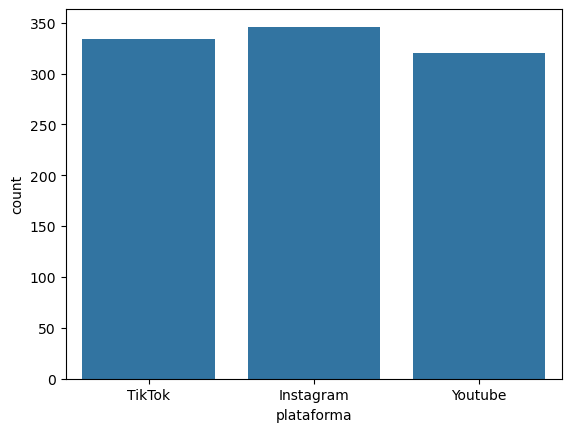

In [34]:
#Usuarios por plataforma 
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [35]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [36]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "nombre"] = None

In [37]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      995 non-null    object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [38]:
#Edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [39]:
df_sucio.describe()["edad"]

count    1000.000000
mean       40.971000
std        14.483782
min       -10.000000
25%        29.000000
50%        41.000000
75%        54.000000
max        65.000000
Name: edad, dtype: float64

In [40]:
#Seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 5000000

In [49]:
df_sucio.describe()["seguidores"]

count      1000.00
mean      50361.59
std      351328.29
min         128.00
25%       13957.25
50%       25340.00
75%       38081.00
max     5000000.00
Name: seguidores, dtype: float64

In [42]:
#Generamos correos invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"] = "correo_invalido"

In [44]:
df_sucio.describe( include = ["object"] )

,nombre,correo,plataforma
count,995,1000,1000
unique,995,996,3
top,Lic. Georgina Lira,correo_invalido,Instagram
freq,1,5,346


In [45]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [47]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [48]:
#estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,995,996,NaN,NaN,3
top,NaN,Lic. Georgina Lira,correo_invalido,NaN,NaN,Instagram
freq,NaN,1,5,NaN,NaN,346
mean,500.50,NaN,NaN,40.97,50361.59,NaN
std,288.82,NaN,NaN,14.48,351328.29,NaN
min,1.00,NaN,NaN,-10.00,128.00,NaN
25%,250.75,NaN,NaN,29.00,13957.25,NaN
50%,500.50,NaN,NaN,41.00,25340.00,NaN
75%,750.25,NaN,NaN,54.00,38081.00,NaN
